# Análise de Investimentos Pessoais

## Contexto
---
Você foi contratado como analista de dados por uma consultoria financeira que auxilia clientes na gestão de suas carteiras de investimento. Um cliente forneceu o histórico de suas aplicações nos últimos meses e deseja compreender melhor o desempenho de seus investimentos, identificar quais ativos geraram maior retorno e avaliar a distribuição de seu portfólio. Sua missão é utilizar **Pandas** para processar esses dados e criar visualizações interativas com **Plotly** que ajudem o cliente a tomar decisões mais informadas sobre seus investimentos futuros.

## Objetivos de Aprendizagem
---
Ao final deste exercício, você será capaz de:
- Explorar e validar dados financeiros de investimentos
- Calcular métricas de rentabilidade e retorno sobre investimento
- Agrupar investimentos por tipo de ativo e categoria de risco
- Filtrar investimentos com base em critérios de performance
- Criar visualizações que comuniquem o desempenho da carteira
- Categorizar investimentos por faixa de rentabilidade

## Competências a Serem Desenvolvidas
---
- Exploração de dados financeiros com estatísticas descritivas
- Criação de colunas derivadas para cálculo de rentabilidade e lucro
- Agrupamento de dados por tipo de ativo e categoria de risco
- Aplicação de filtros para identificar investimentos de alta performance
- Categorização de rentabilidade com `pd.cut()` e manipulação de datas com `pd.to_datetime()`
- Construção de gráficos interativos com Plotly (dispersão, barras, pizza e barras empilhadas)

## Dependências e Configurações
---
Antes de iniciar a análise, importe as bibliotecas necessárias.

In [10]:
# Importar bibliotecas
import pandas as pd
import plotly.express as px

# Configuração opcional para melhor visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
# pd.set_option('display.float_format', lambda x: f'R$ {x:,.2f}')

## Conjunto de Dados

---
Crie um DataFrame com os seguintes dados:

```python
{
    'Investimento_ID': [201, 202, 203, 204, 205, 206, 207, 208, 209, 210],
    'Ativo': ['Ações', 'Tesouro Direto', 'CDB', 'Ações', 'Fundos Imobiliários', 'CDB', 'Ações', 'Tesouro Direto', 'Fundos Imobiliários', 'CDB'],
    'Categoria_Risco': ['Alto', 'Baixo', 'Médio', 'Alto', 'Médio', 'Médio', 'Alto', 'Baixo', 'Médio', 'Médio'],
    'Valor_Investido': [5000.0, 3000.0, 2000.0, 4500.0, 3500.0, 2500.0, 6000.0, 4000.0, 3000.0, 1500.0],
    'Valor_Atual': [5800.0, 3150.0, 2100.0, 4200.0, 3700.0, 2650.0, 6900.0, 4200.0, 3300.0, 1575.0],
    'Data_Aplicacao': ['2023-01-15', '2023-02-10', '2023-02-20', '2023-03-05', '2023-03-15', '2023-04-01', '2023-04-20', '2023-05-10', '2023-05-25', '2023-06-15'],
    'Prazo_Meses': [12, 24, 18, 12, 36, 18, 12, 24, 36, 18]
}
```

**Descrição das Colunas:**
- `Investimento_ID`: Identificador único do investimento
- `Ativo`: Tipo de ativo financeiro (Ações, Tesouro Direto, CDB, Fundos Imobiliários)
- `Categoria_Risco`: Classificação de risco do investimento (Baixo, Médio, Alto)
- `Valor_Investido`: Valor inicial aplicado em reais
- `Valor_Atual`: Valor atual do investimento em reais
- `Data_Aplicacao`: Data em que o investimento foi realizado
- `Prazo_Meses`: Prazo previsto do investimento em meses

In [12]:
try:
    df = pd.DataFrame(
            {
                'Investimento_ID': [201, 202, 203, 204, 205, 206, 207, 208, 209, 210],
                'Ativo': ['Ações', 'Tesouro Direto', 'CDB', 'Ações', 'Fundos Imobiliários', 'CDB', 'Ações', 'Tesouro Direto', 'Fundos Imobiliários', 'CDB'],
                'Categoria_Risco': ['Alto', 'Baixo', 'Médio', 'Alto', 'Médio', 'Médio', 'Alto', 'Baixo', 'Médio', 'Médio'],
                'Valor_Investido': [5000.0, 3000.0, 2000.0, 4500.0, 3500.0, 2500.0, 6000.0, 4000.0, 3000.0, 1500.0],
                'Valor_Atual': [5800.0, 3150.0, 2100.0, 4200.0, 3700.0, 2650.0, 6900.0, 4200.0, 3300.0, 1575.0],
                'Data_Aplicacao': ['2023-01-15', '2023-02-10', '2023-02-20', '2023-03-05', '2023-03-15', '2023-04-01', '2023-04-20', '2023-05-10', '2023-05-25', '2023-06-15'],
                'Prazo_Meses': [12, 24, 18, 12, 36, 18, 12, 24, 36, 18]
            }
    )
    print('\n=== Dados carregados ===\n')
except Exception as e:
    raise ValueError(f'Erro inesperado: {e}')


=== Dados carregados ===



## Tarefas
---
### 1. Exploração Inicial
- Exibir as cinco primeiras linhas do DataFrame  
  *Dica: Utilize um método que permite visualizar as primeiras entradas de um DataFrame.*

In [6]:
df.head()

,Investimento_ID,Ativo,Categoria_Risco,Valor_Investido,Valor_Atual,Data_Aplicacao,Prazo_Meses
0,201,Ações,Alto,"R$ 5,000.00","R$ 5,800.00",2023-01-15,12
1,202,Tesouro Direto,Baixo,"R$ 3,000.00","R$ 3,150.00",2023-02-10,24
2,203,CDB,Médio,"R$ 2,000.00","R$ 2,100.00",2023-02-20,18
3,204,Ações,Alto,"R$ 4,500.00","R$ 4,200.00",2023-03-05,12
4,205,Fundos Imobiliários,Médio,"R$ 3,500.00","R$ 3,700.00",2023-03-15,36


- Verificar a existência de valores ausentes  
  *Dica: Explore funções que ajudam a identificar dados nulos em cada coluna.*

In [8]:
df.isna().sum()

Investimento_ID    0
Ativo              0
Categoria_Risco    0
Valor_Investido    0
Valor_Atual        0
Data_Aplicacao     0
Prazo_Meses        0
dtype: int64

- Apresentar estatísticas descritivas das colunas `Valor_Investido` e `Valor_Atual`  
  *Dica: Utilize métodos que geram resumos estatísticos para colunas numéricas.*

In [13]:
df[['Valor_Investido', 'Valor_Atual']].describe()

,Valor_Investido,Valor_Atual
count,R$ 10.00,R$ 10.00
mean,"R$ 3,500.00","R$ 3,757.50"
std,"R$ 1,394.43","R$ 1,624.72"
min,"R$ 1,500.00","R$ 1,575.00"
25%,"R$ 2,625.00","R$ 2,775.00"
50%,"R$ 3,250.00","R$ 3,500.00"
75%,"R$ 4,375.00","R$ 4,200.00"
max,"R$ 6,000.00","R$ 6,900.00"


- Visualização: Criar um gráfico de dispersão com Plotly, relacionando `Valor_Investido` (eixo x) e `Valor_Atual` (eixo y), com cores diferenciadas por `Ativo`  
  *Dica: Considere utilizar uma função de Plotly Express voltada para visualizações de dispersão, que permite identificar a relação entre valores investidos e retornos.*

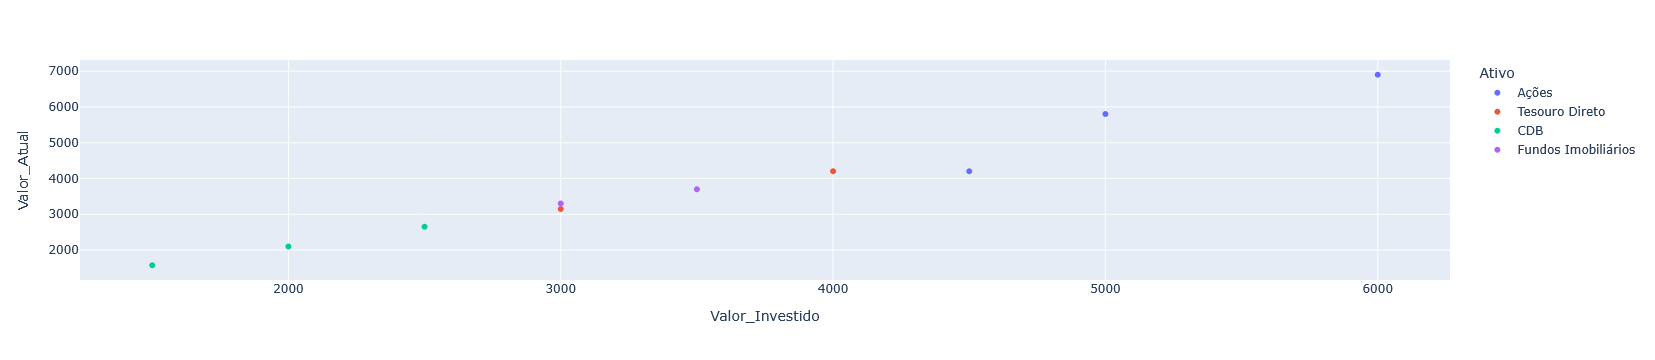

In [16]:
fig = px.scatter(
    df,
    x='Valor_Investido',
    y='Valor_Atual',
    color='Ativo'
)
fig.show()

---
### 2. Cálculos Básicos
- Criar a coluna `Lucro`, calculando a diferença entre o valor atual e o valor investido (`Valor_Atual` - `Valor_Investido`)  
  *Dica: Use operações vetoriais para criar colunas derivadas com base em cálculos entre colunas existentes.*

- Criar a coluna `Rentabilidade_Percentual`, calculando o percentual de retorno do investimento ((`Valor_Atual` - `Valor_Investido`) / `Valor_Investido` × 100)  
  *Dica: Lembre-se de multiplicar por 100 para obter o resultado em porcentagem.*

- Calcular o lucro total de todos os investimentos  
  *Dica: Utilize uma função de agregação que retorna a soma dos valores de uma coluna.*

- Visualização: Construir um gráfico de barras com Plotly exibindo o `Lucro` por `Investimento_ID`  
  *Dica: Explore a função de Plotly Express que permite criar gráficos de barras simples, facilitando a comparação entre investimentos.*

---
### 3. Análise por Agrupamento
- Agrupar os dados por `Ativo` e calcular a média de `Rentabilidade_Percentual` e a soma do `Valor_Investido`  
  *Dica: Utilize o método de agrupamento do Pandas e aplique funções estatísticas sobre os grupos formados para identificar qual ativo teve melhor desempenho.*

- Agrupar os dados por `Categoria_Risco` e calcular o lucro total (`Lucro`) por categoria  
  *Dica: Após agrupar os dados por categoria, aplique uma função de agregação para obter o total por grupo.*

- Visualização: Criar um gráfico de pizza com Plotly mostrando a distribuição do `Valor_Investido` por `Ativo`  
  *Dica: Use uma função de Plotly Express específica para gráficos de pizza, ideal para visualizar a composição percentual da carteira.*

---
### 4. Aplicação de Filtros
- Filtrar os investimentos com `Rentabilidade_Percentual` superior a 10%  
  *Dica: Utilize expressões condicionais para selecionar linhas com base em valores de uma coluna.*

- Filtrar os investimentos da categoria de risco "Alto" com `Lucro` superior a R$ 500,00  
  *Dica: Combine múltiplas condições lógicas usando operadores como & (E) para aplicar filtros compostos.*

- Visualização: Criar um gráfico de barras com Plotly para os investimentos filtrados com rentabilidade superior a 10%, exibindo `Rentabilidade_Percentual` por `Ativo`, com cores por `Categoria_Risco`  
  *Dica: Considere uma função de Plotly Express que permita destacar categorias por cor em gráficos de barras, facilitando a análise de risco versus retorno.*

---
### 5. Extra (Desafio)
- Converter a coluna `Data_Aplicacao` para o formato datetime  
  *Dica: Utilize uma função do Pandas que transforma strings em objetos de data, permitindo análises temporais.*

- Criar uma nova coluna `Faixa_Rentabilidade` que classifique os investimentos como "Baixa" (< 5%), "Moderada" (5–15%) ou "Alta" (> 15%)  
  *Dica: Explore funções que permitem segmentar valores numéricos em faixas categóricas, úteis para classificar performance.*

- Identificar qual categoria de risco (Baixo, Médio ou Alto) teve a maior rentabilidade média percentual e exibir o resultado  
  *Dica: Agrupe os dados por categoria de risco e utilize uma função estatística para comparar os valores médios entre os grupos.*

- Visualização: Criar um gráfico de barras empilhadas com Plotly mostrando a contagem de investimentos por `Faixa_Rentabilidade` em cada `Categoria_Risco`  
  *Dica: Utilize uma função de Plotly Express que permita empilhar categorias dentro de grupos em gráficos de barras, revelando a distribuição de performance por nível de risco.*

---
## Reflexão e Perguntas Adicionais
---
Após concluir as tarefas, reflita sobre os seguintes pontos:

1. **Padrões Identificados**: Quais tipos de ativos apresentaram melhor rentabilidade? Existe uma correlação clara entre categoria de risco e retorno obtido?

2. **Qualidade dos Dados**: Os dados estavam completos e bem estruturados? Como você lidaria com investimentos que ainda não atingiram a maturidade ou que apresentam valores negativos?

3. **Insights para o Negócio**: Com base na sua análise, quais recomendações você daria para o cliente sobre diversificação da carteira e equilíbrio entre risco e retorno?

4. **Próximos Passos**: Que outras análises você poderia realizar com esses dados? Pense em análises de prazo médio de investimento, projeções de retorno futuro ou comparação com benchmarks de mercado.

5. **Visualizações**: As visualizações criadas comunicam claramente o desempenho da carteira? Qual visualização foi mais efetiva para identificar oportunidades de melhoria?

---
## Recursos Adicionais
---
Para aprofundar seus conhecimentos:
- **Documentação do Pandas**: https://pandas.pydata.org/docs/
- **Documentação do Plotly**: https://plotly.com/python/
- **Tutoriais de Análise de Dados**: Explore cursos online e notebooks no Kaggle
- **Análise Financeira com Python**: Busque materiais específicos sobre finanças quantitativas